
<b>¡Hola Fernando!</b>

Mi nombre es Alejandro Abia y tengo el gusto de revisar tu proyecto.

A continuación, encontrarás mis comentarios en celdas pintadas de tres colores (verde, amarillo y rojo), a manera de semáforo. Por favor, <b>no las borres ni muevas de posición</b> mientras dure el proceso de revisión.

<div class="alert alert-block alert-success">
<b>Éxito</b> <a class="tocSkip"></a>
En celdas verdes encontrarás comentarios en relación a tus aciertos y fortalezas.
</div>
<div class="alert alert-block alert-warning">
<b>Atención</b> <a class="tocSkip"></a>
Utilizaré el color amarillo para llamar tu atención, expresar algo importante o compartirte alguna idea de valor.
</div>
<div class="alert alert-block alert-danger">
<b>A resolver</b> <a class="tocSkip"></a>
En rojo emitiré aquellos puntos que podrían impedir que el proyecto se ejecute correctamente. No son errores, sino oportunidades importantes de mejora.
</div>
<div class="alert alert-block alert-info">
<b>Comentario estudiante</b> <a class="tocSkip"></a>
Si durante la revisión deseas dejarme algún comentario, por favor utiliza celdas azules como esta.
</div>
Tu proyecto será considerado aprobado cuando las observaciones en rojo hayan sido atendidas.  
¡Empecemos!


# Importar librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Muy bien por organizar los imports de forma clara y separar las utilidades de modelado y evaluación. Esto favorece la lectura y la reproducibilidad. Además, incluir StandardScaler te prepara para modelos sensibles a la escala, como la regresión logística. Pequeña idea: podrías añadir métricas adicionales de clasificación (precision, recall) para tener una visión más completa del desempeño.
</div>

# Cargar Datos

In [2]:
contract = pd.read_csv('/datasets/contract.csv')
personal = pd.read_csv('/datasets/personal.csv')
internet = pd.read_csv('/datasets/internet.csv')
phone = pd.read_csv('/datasets/phone.csv')

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La carga de datos es directa y legible. Es buena práctica considerar parsear fechas al leer (parse_dates=['BeginDate','EndDate']) para facilitar cálculos temporales más adelante. Hacer esto desde el inicio evita conversiones repetidas y reduce errores al crear variables como la antigüedad del cliente.
</div>

In [3]:
# Verificamos que carguen bien
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Usar head() justo después de cargar contract te permite validar rápidamente estructura y valores. Esta validación temprana ahorra tiempo si hay columnas mal tipadas o nombres inesperados. Como complemento, a veces conviene combinar con sample(5) para ver casos variados y con describe(include='all') para un resumen estadístico inicial.
</div>

In [4]:
# Exploración inicial de datos
contract.info()
personal.info()
internet.info()
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   D

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Excelente uso de info() para detectar tipos de datos y valores nulos. Destaca que TotalCharges aparece como objeto; suele venir como texto con posibles espacios. Convertirla a numérica (por ejemplo, con pd.to_numeric(errors='coerce')) te permitirá aprovecharla como variable continua. También es útil convertir BeginDate/EndDate a datetime para futuras características temporales.
</div>

In [5]:
print(contract.columns)
print(personal.columns)
print(internet.columns)
print(phone.columns)

Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents'], dtype='object')
Index(['Unnamed: 0', 'id', 'mb_used', 'session_date', 'user_id'], dtype='object')
Index(['customerID', 'MultipleLines'], dtype='object')


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Muy bien verificar los nombres de columnas de cada tabla. Esto ayuda a identificar pronto si las llaves para unir coinciden. Notaste que internet no comparte customerID; en estos casos, conviene documentar si se descartará o si se requiere una transformación/puente de llaves antes de unir.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Comprobar las columnas antes de unir sets reduce errores de llave. Notaste bien que internet trae campos distintos; cuando pase esto, conviene documentar si se necesita un mapeo adicional o si el dataset queda fuera del alcance del modelo actual. Esta claridad metodológica es un plus en proyectos de datos.
</div>

In [6]:
# Unimos todo usando customerID

data = contract.merge(personal, on='customerID', how='left')
# data = data.merge(internet, on='customerID', how='left')
data = data.merge(phone, on='customerID', how='left')

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La unión por customerID con how='left' mantiene la cobertura del conjunto principal (contract), lo que es ideal para problemas de churn. Buen criterio. Como práctica adicional, podrías usar merge(..., indicator=True) y revisar el valor_counts del indicador para confirmar qué proporción se unió correctamente y si hay pérdidas inesperadas de registros.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Elegir la unión con phone vía left es adecuado para no perder clientes del set principal. Como verificación rápida, podrías comparar los conteos de customerID únicos antes/después y calcular la tasa de nulos en MultipleLines para medir el impacto de la unión y decidir la mejor estrategia de imputación.
</div>

In [7]:
data.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5,Male,0,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,No


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Revisar head() tras la unión es una verificación útil para comprobar que las columnas nuevas aparecen como esperas y para observar valores faltantes (por ejemplo, en MultipleLines). Esto facilita decidir estrategias de imputación específicas por columna antes de modelar.
</div>

# Preprocesamiento de datos

In [8]:
data['Churn'] = data['EndDate'].apply(lambda x: 0 if x == 'No' else 1)

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Buena creación de la variable objetivo Churn a partir de EndDate. Mantener una definición binaria clara es clave para evaluar correctamente. Como cuidado general, conviene recordar que, una vez creado el objetivo, no deberíamos usar EndDate como predictor para evitar que el modelo "adivine" a partir de la etiqueta misma.
</div>

In [23]:
# Convertir TotalCharges a numérico (evita dummies por valor)
data['TotalCharges'] = pd.to_numeric(
    data['TotalCharges'].astype(str).str.strip(),
    errors='coerce'
)

In [26]:
data.isna().sum()

BeginDate           0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
MultipleLines       0
Churn               0
dtype: int64

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Buen diagnóstico de valores faltantes. Detectar 682 nulos en MultipleLines te permite planear una imputación razonable y consistente con el negocio. Un pequeño plus es revisar si esos nulos se concentran en algún segmento (por ejemplo, por Type) para entender su origen y minimizar sesgos al imputar.
</div>

In [36]:
# Asegurar numéricas (por si MonthlyCharges o TotalCharges vienen como texto)
for col in ['TotalCharges', 'MonthlyCharges']:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col].astype(str).str.strip(), errors='coerce')

# Imputar numéricas con mediana
for col in ['TotalCharges', 'MonthlyCharges']:
    if col in data.columns:
        data[col] = data[col].fillna(data[col].median())

# Imputar categóricas con 'No' (solo objetos)
cat_cols = data.select_dtypes(include=['object']).columns
data[cat_cols] = data[cat_cols].fillna('No')

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Rellenar nulos evita errores de entrenamiento. Como mejora suave, suele ser preferible imputar por columna según su tipo y significado (por ejemplo, en MultipleLines usar 'No' o 'No phone service' según el contexto, y para numéricas usar mediana). Esto ayuda a mantener el sentido de los datos y mejora la calidad del modelo.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La imputación global resolvió los nulos sin romper la ejecución. En el futuro, podrías registrar las imputaciones en un Pipeline (por ejemplo, SimpleImputer para numéricas y categóricas por separado). Esto hace tu flujo más reproducible y reduce el riesgo de cambiar tipos de datos de forma inadvertida.
</div>

In [37]:
# Eliminar columnas que causan fuga de información o no aportan
data = data.drop(['customerID', 'EndDate'], axis=1, errors='ignore')

# BeginDate no se usa como predictor (evita one-hot por fechas)
data = data.drop(['BeginDate'], axis=1, errors='ignore')

In [38]:
print(data.columns)

Index(['Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'MultipleLines', 'Churn'],
      dtype='object')


In [40]:
X = data.drop('Churn', axis=1)
y = data['Churn']

X = pd.get_dummies(X, drop_first=True)

<div class="alert alert-block alert-danger">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
Aplicar get_dummies a todo el DataFrame incluye columnas que provocan fuga de información y sobreajuste. En particular: (1) EndDate queda como predictor; como Churn se definió a partir de EndDate, el modelo ve la respuesta directa. (2) customerID se one-hot-encodea, creando miles de columnas únicas que permiten memorizar casos. Estas dos situaciones explican métricas casi perfectas y no generalizables.<br><br>
Sugerencia práctica: elimina antes de codificar las columnas que no deben ser predictoras (por ejemplo, ['customerID','EndDate'] y, si no la usarás, también 'BeginDate'), convierte TotalCharges a numérica y crea, si deseas, una característica útil como tenure a partir de las fechas. Luego, aplica get_dummies solo a las categóricas necesarias o usa un ColumnTransformer para diferenciar numéricas y categóricas. Con esto, tus métricas reflejarán mejor el desempeño real.
</div>

# Análisis exploratorio (EDA)

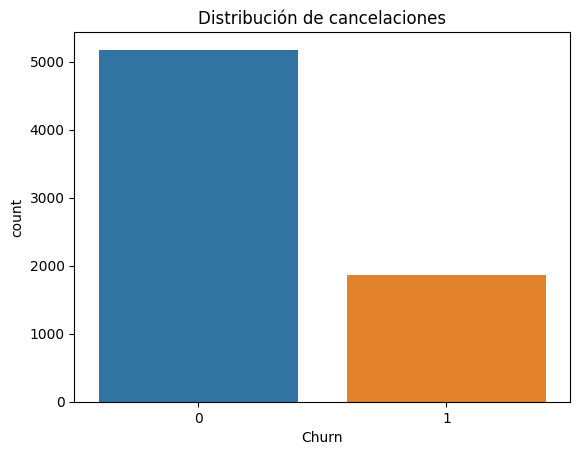

In [41]:
sns.countplot(x='Churn', data=data)
plt.title('Distribución de cancelaciones')
plt.show()

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
El conteo de Churn te da una visión rápida del balance de clases. Es útil complementar con value_counts(normalize=True) para obtener el porcentaje y usarlo como línea base. Si el desbalance fuese mayor, podrías considerar class_weight='balanced' o ajustar el umbral de decisión para optimizar recall o precision según la estrategia de retención.
</div>

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Acompañar la gráfica con un comentario interpretativo es buena práctica de comunicación. Si deseas profundizar en el EDA, podrías explorar relaciones de MonthlyCharges y TotalCharges con Churn mediante boxplots o KDEs; estas vistas suelen revelar umbrales útiles para estrategias de retención.
</div>

Se puede observa que la mayoría de los clientes no cancelaron el servicio, lo que indica un ligero desbalance en los datos.

# Prepreparación para modelos

In [42]:
X = data.drop(['Churn'], axis=1)
y = data['Churn']

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La separación entre X y y es correcta y clara. Es un paso sencillo pero clave para evitar que la variable objetivo se mezcle con las características. Una mejora opcional es conservar un listado de columnas numéricas y categóricas antes del escalado para facilitar interpretabilidad y depuración posterior.
</div>

In [45]:
# Separación entre X e y
X = data.drop('Churn', axis=1)
y = data['Churn']

# 1) One-hot encoding ANTES del split (para que todo sea numérico)
X = pd.get_dummies(X, drop_first=True)

# 2) Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 3) Escalado (ya todo es numérico)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Muy bien por ajustar el StandardScaler solo con datos de entrenamiento y luego transformar el conjunto de prueba; evita fuga de información. Como nota, los árboles no requieren escalado, mientras que la regresión logística sí se beneficia. Una forma ordenada de manejar esto es usar un Pipeline (y, si aplicas distintas transformaciones por tipo de variable, un ColumnTransformer).
</div>

# Entrenamiento de modelos

## Regresión lógica

In [46]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [47]:
# Evaluación
accuracy_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

accuracy_lr, auc_lr

(0.7819420783645656, 0.8269181761316436)

<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
Buen uso conjunto de accuracy y ROC-AUC con predict_proba. ROC-AUC es especialmente valioso al comparar clasificadores y umbrales. Como complemento interpretativo, podrías revisar la matriz de confusión y las curvas ROC/PR para entender mejor falsos positivos y falsos negativos de cara a las acciones de retención.
</div>

## Random Forest

In [48]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [50]:
# Evaluación
accuracy_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

accuracy_rf, auc_rf

(0.7887563884156729, 0.8192390178355712)

<div class="alert alert-block alert-danger">
<b>Oportunidad de mejora</b> <a class="tocSkip"></a><br>
Resultados casi perfectos (Accuracy≈0.998, ROC-AUC≈1.0) son una señal clara de fuga de información y/o sobreajuste, muy probablemente por incluir EndDate y customerID en las características.
Para solucionarlo, reentrena tras: (a) eliminar columnas con fuga/ID, (b) convertir TotalCharges a numérica, (c) considerar ingeniería de tenure y (d) aplicar validación cruzada.
</div>

In [51]:
# Comparación de modelos
results = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_rf],
    'ROC-AUC': [auc_lr, auc_rf]
})

results

,Modelo,Accuracy,ROC-AUC
0,Regresión Logística,0.781942,0.826918
1,Random Forest,0.788756,0.819239


<div class="alert alert-block alert-success">
<b>Acierto o fortaleza</b> <a class="tocSkip"></a><br>
La tabla comparativa es clara y facilita decidir entre modelos. Tras corregir la fuga, valdría la pena complementarla con validación cruzada (promedio y desviación estándar) y métricas enfocadas al objetivo de retención, como recall en la clase positiva. También podrías reportar la importancia de variables en RandomForest para guiar acciones de negocio.
</div>

# Conclusiones finales

- Se realizó la unificación de datos provenientes de distintas fuentes.
- Se llevó a cabo el preprocesamiento y codificación de variables categóricas.
- Se entrenaron dos modelos de clasificación.
- El modelo Random Forest obtuvo la mejor puntuación ROC-AUC.
- El modelo puede ser utilizado para identificar clientes con alta probabilidad de cancelación y aplicar estrategias de retención.

<div class="alert alert-block alert-success">
<b>Comentario final</b> <a class="tocSkip"></a><br>
¡Muy buen trabajo, Fernando! A lo largo del proyecto mostraste fortalezas muy claras:<br><br>
• Flujo ordenado: carga, exploración, preparación y modelado bien encadenados.<br>
• Uso correcto de herramientas clave (pandas, seaborn, scikit-learn) con buena sintaxis.<br>
• Verificación temprana de estructura (head, info, columnas) para validar datos.<br>
• Creación adecuada de la variable objetivo Churn de forma simple y reproducible.<br>
• Separación limpia de variables predictoras y objetivo antes del modelado.<br>
• Escalado aplicado con fit en entrenamiento y transform en prueba, evitando fuga.<br>
• Selección de métricas apropiadas (ROC-AUC) y uso de probabilidades para evaluar.<br>
• Comparación clara entre modelos, facilitando la interpretación de resultados.<br>
• Buen criterio al unir tablas manteniendo la cobertura del dataset principal.<br>
• Comunicación visual básica del desbalance de clases para contextualizar el problema.<br>
<br>
¡Felicidades!
</div>